# WM 2026 – CV Block: Trikot-Klassifikation

Dieses Notebook trainiert einen ViT-basierten Bildklassifikator, der anhand eines Trikotfotos die Nation erkennt.

**Pipeline:**  
**`CV (Trikot → Nation)`** → `ML (Nation → WM-Prognose)` → `NLP (Prognose → Erklärung)`

Basiert auf demselben Ansatz wie Übung 2 (Pokemon-Klassifikation), angewendet auf 16 WM-Nationen.

---

## Setup

In [1]:
import subprocess, sys

# Pakete direkt in der aktiven Kernel-Umgebung installieren
packages = [
    "accelerate>=1.1.0",
    "transformers",
    "datasets",
    "evaluate",
    "torch",
    "torchvision",
    "huggingface_hub",
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

# Verifizieren
import accelerate
print(f"Python:     {sys.executable}")
print(f"accelerate: {accelerate.__version__}")
print("Alle Pakete bereit ✓")

Python:     /opt/anaconda3/bin/python
accelerate: 1.13.0
Alle Pakete bereit ✓


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import (
    ViTForImageClassification,
    ViTImageProcessor,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset as HFDataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DATA_DIR   = Path('../../data/jerseys')
MODEL_DIR  = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

HF_MODEL_NAME = 'tschool01/wm2026-jersey-classifier'

NATIONS = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f'{len(NATIONS)} Nationen: {NATIONS}')

16 Nationen: ['argentina', 'australia', 'belgium', 'brazil', 'colombia', 'croatia', 'england', 'france', 'germany', 'japan', 'netherlands', 'portugal', 'southafrica', 'spain', 'switzerland', 'usa']


## 1. Daten-Check & EDA

In [3]:
# Bilder pro Nation zählen
counts = {}
for nation in NATIONS:
    imgs = list((DATA_DIR / nation).glob('*.jpg')) + \
           list((DATA_DIR / nation).glob('*.jpeg')) + \
           list((DATA_DIR / nation).glob('*.png')) + \
           list((DATA_DIR / nation).glob('*.webp'))
    counts[nation] = len(imgs)

print('Bilder pro Nation:')
for k, v in sorted(counts.items()):
    bar = '█' * v
    print(f'  {k:15s}: {v:3d}  {bar}')

print(f'\nGesamt: {sum(counts.values())} Bilder')

if any(v == 0 for v in counts.values()):
    print('\n⚠️  Leere Ordner gefunden! Bilder sammeln bevor Training startet.')

Bilder pro Nation:
  argentina      :  25  █████████████████████████
  australia      :  25  █████████████████████████
  belgium        :  25  █████████████████████████
  brazil         :  25  █████████████████████████
  colombia       :  25  █████████████████████████
  croatia        :  25  █████████████████████████
  england        :  25  █████████████████████████
  france         :  25  █████████████████████████
  germany        :  25  █████████████████████████
  japan          :  25  █████████████████████████
  netherlands    :  25  █████████████████████████
  portugal       :  25  █████████████████████████
  southafrica    :  25  █████████████████████████
  spain          :  25  █████████████████████████
  switzerland    :  25  █████████████████████████
  usa            :  25  █████████████████████████

Gesamt: 400 Bilder


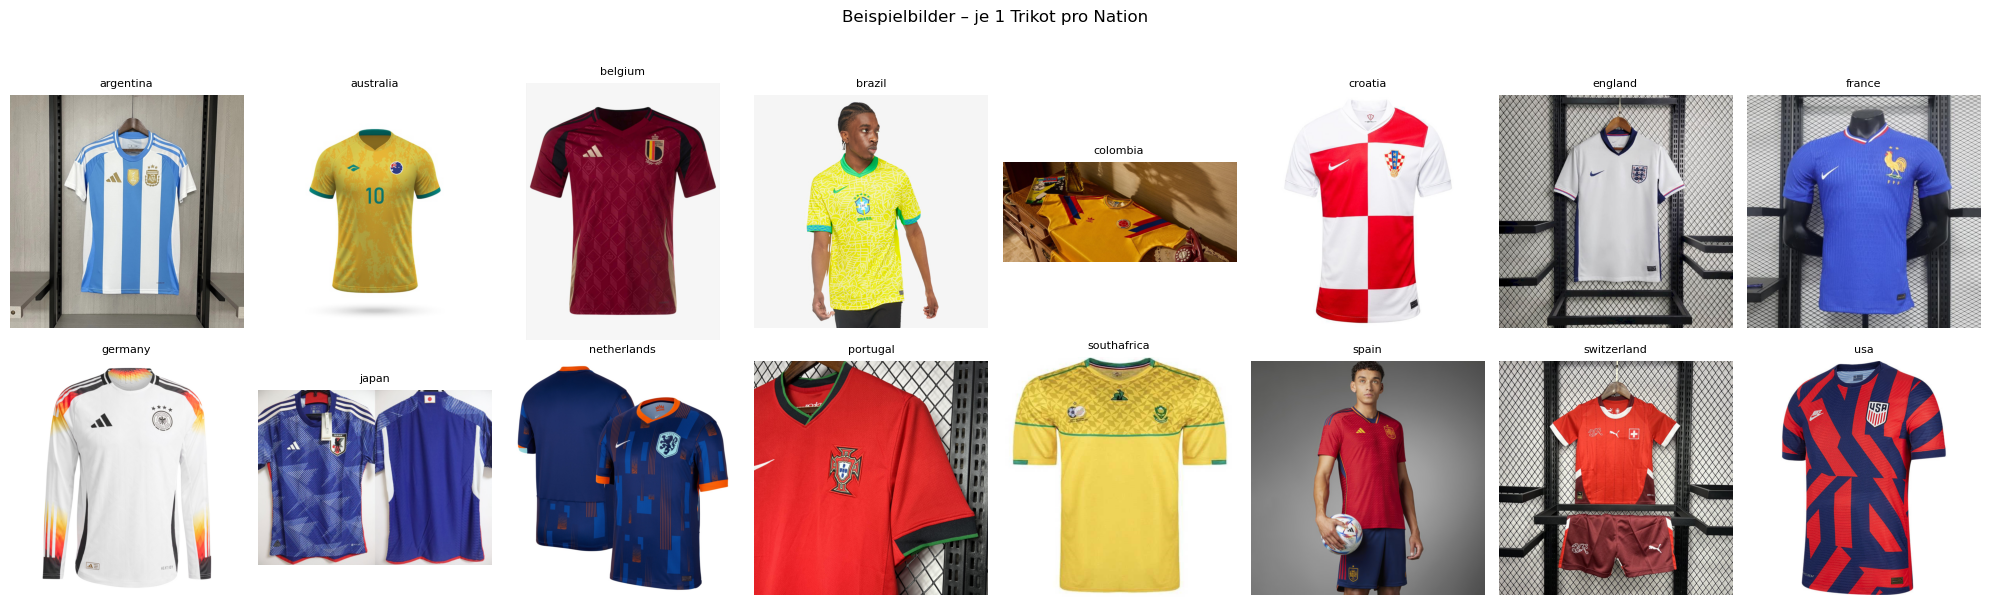

In [4]:
# Beispielbilder anzeigen (je 1 pro Nation)
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
axes = axes.flatten()

for i, nation in enumerate(NATIONS):
    imgs = list((DATA_DIR / nation).glob('*.*'))
    if imgs:
        img = Image.open(imgs[0]).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(nation, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Beispielbilder – je 1 Trikot pro Nation', y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'eda_samples.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Daten vorbereiten

**Preprocessing:** Resize auf 224×224, Normalisierung nach ImageNet-Standard.  
**Augmentation:** Random Horizontal Flip, Colour Jitter (nur Training).

In [5]:
label2id = {n: i for i, n in enumerate(NATIONS)}
id2label = {i: n for n, i in label2id.items()}
print('Label-Mapping:', label2id)

# Alle Bildpfade + Labels einlesen
all_paths, all_labels = [], []
for nation in NATIONS:
    imgs = list((DATA_DIR / nation).glob('*.jpg')) + \
           list((DATA_DIR / nation).glob('*.jpeg')) + \
           list((DATA_DIR / nation).glob('*.png')) + \
           list((DATA_DIR / nation).glob('*.webp'))
    for p in imgs:
        all_paths.append(str(p))
        all_labels.append(label2id[nation])

print(f'Gesamt: {len(all_paths)} Bilder')

Label-Mapping: {'argentina': 0, 'australia': 1, 'belgium': 2, 'brazil': 3, 'colombia': 4, 'croatia': 5, 'england': 6, 'france': 7, 'germany': 8, 'japan': 9, 'netherlands': 10, 'portugal': 11, 'southafrica': 12, 'spain': 13, 'switzerland': 14, 'usa': 15}
Gesamt: 400 Bilder


In [6]:
from sklearn.model_selection import train_test_split

# 70% Train / 15% Val / 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 280 | Val: 60 | Test: 60


In [7]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

class JerseyDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        pixel_values = self.transform(img)
        return {'pixel_values': pixel_values, 'labels': self.labels[idx]}

train_ds = JerseyDataset(X_train, y_train, train_transforms)
val_ds   = JerseyDataset(X_val,   y_val,   val_transforms)
test_ds  = JerseyDataset(X_test,  y_test,  val_transforms)

print(f'Datasets bereit: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}')

Datasets bereit: 280 / 60 / 60


## 3. Modell – Iteration 1: ViT Transfer Learning (Baseline)

**Modell:** `google/vit-base-patch16-224-in21k` (vortrainiert auf ImageNet-21k)  
**Strategie:** Nur den Klassifikations-Head neu trainieren (frozen backbone)

In [8]:
def load_vit(freeze_backbone=True):
    model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224-in21k',
        num_labels=len(NATIONS),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainierbare Parameter: {trainable:,} / {total:,}')
    return model

model_iter1 = load_vit(freeze_backbone=True)

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

Trainierbare Parameter: 12,304 / 85,810,960


In [9]:
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

training_args_iter1 = TrainingArguments(
    output_dir=str(MODEL_DIR / 'vit-iter1'),
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-4,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=10,
    report_to='none',
)

trainer_iter1 = Trainer(
    model=model_iter1,
    args=training_args_iter1,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print('Training Iteration 1 startet...')
trainer_iter1.train()

Training Iteration 1 startet...


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,2.780697,2.747773,0.150000
2,2.727569,2.719917,0.133333
3,2.691582,2.700904,0.133333
4,2.666450,2.690117,0.133333
5,2.667689,2.686334,0.133333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=90, training_loss=2.7106565051608618, metrics={'train_runtime': 72.1771, 'train_samples_per_second': 19.397, 'train_steps_per_second': 1.247, 'total_flos': 1.08502398369792e+17, 'train_loss': 2.7106565051608618, 'epoch': 5.0})

In [10]:
# Iteration 1 – Evaluation auf Val-Set
results_iter1 = trainer_iter1.evaluate()
print('Iteration 1 Val-Accuracy:', results_iter1['eval_accuracy'])

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
2.667689,2.747773,5,0.150000


Iteration 1 Val-Accuracy: 0.15


## 4. Modell – Iteration 2: Fine-Tuning (Full Backbone)

**Änderungen gegenüber Iter. 1:**
- Gesamter Backbone wird trainiert (kein Freeze)
- Niedrigere Learning Rate (1e-5)
- Mehr Augmentation

In [11]:
model_iter2 = load_vit(freeze_backbone=False)

training_args_iter2 = TrainingArguments(
    output_dir=str(MODEL_DIR / 'vit-iter2'),
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=10,
    report_to='none',
)

trainer_iter2 = Trainer(
    model=model_iter2,
    args=training_args_iter2,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print('Training Iteration 2 startet...')
trainer_iter2.train()

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

Trainierbare Parameter: 85,810,960 / 85,810,960
Training Iteration 2 startet...


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,2.779389,2.728273,0.166667
2,2.660764,2.577487,0.166667
3,2.461267,2.392387,0.233333
4,2.256943,2.295848,0.250000
5,2.161889,2.236189,0.283333
6,2.088026,2.223642,0.283333
7,2.024495,2.162331,0.283333
8,1.997761,2.130435,0.316667
9,1.923826,2.121156,0.316667
10,1.926966,2.120252,0.316667


...

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=180, training_loss=2.224211343129476, metrics={'train_runtime': 492.1591, 'train_samples_per_second': 5.689, 'train_steps_per_second': 0.366, 'total_flos': 2.17004796739584e+17, 'train_loss': 2.224211343129476, 'epoch': 10.0})

In [12]:
results_iter2 = trainer_iter2.evaluate()
print('Iteration 2 Val-Accuracy:', results_iter2['eval_accuracy'])

print('\nVergleich:')
print(f'  Iter 1 (frozen):     {results_iter1["eval_accuracy"]:.3f}')
print(f'  Iter 2 (full FT):    {results_iter2["eval_accuracy"]:.3f}')

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
1.926966,2.130435,10,0.316667


Iteration 2 Val-Accuracy: 0.31666666666666665

Vergleich:
  Iter 1 (frozen):     0.150
  Iter 2 (full FT):    0.317


## 5. Evaluation auf Test-Set

In [13]:
# Bestes Modell auf Test-Set evaluieren
best_trainer = trainer_iter2  # ggf. trainer_iter1 falls Iter 1 besser

test_results = best_trainer.predict(test_ds)
preds = np.argmax(test_results.predictions, axis=-1)
true  = test_results.label_ids

print('Test-Set Accuracy:', (preds == true).mean())
print()
print(classification_report(true, preds, target_names=NATIONS))

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test-Set Accuracy: 0.38333333333333336

              precision    recall  f1-score   support

   argentina       0.33      0.67      0.44         3
   australia       0.25      0.67      0.36         3
     belgium       0.43      0.75      0.55         4
      brazil       0.00      0.00      0.00         4
    colombia       1.00      0.25      0.40         4
     croatia       1.00      0.25      0.40         4
     england       0.44      1.00      0.62         4
      france       0.33      0.25      0.29         4
     germany       0.25      0.25      0.25         4
       japan       1.00      0.50      0.67         4
 netherlands       0.00      0.00      0.00         4
    portugal       0.00      0.00      0.00         3
 southafrica       1.00      0.50      0.67         4
       spain       0.12      0.25      0.17         4
 switzerland       0.00      0.00      0.00         3
         usa       0.43      0.75      0.55         4

    accuracy                           0

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


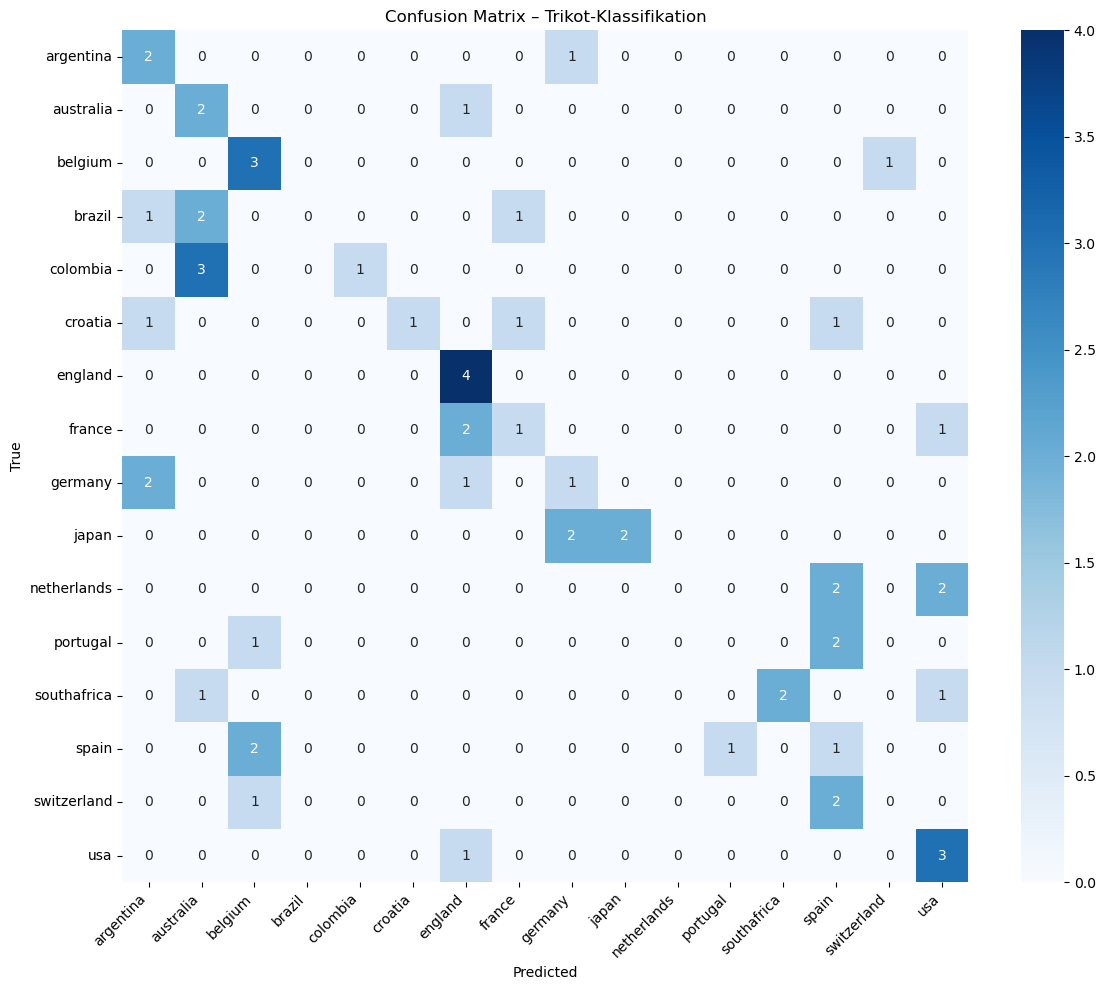

In [14]:
# Confusion Matrix
cm = confusion_matrix(true, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=NATIONS, yticklabels=NATIONS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Trikot-Klassifikation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'cv_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Modell auf Hugging Face hochladen

In [20]:
import getpass
hf_token = getpass.getpass("Hugging Face Token eingeben: ")
print("Token gespeichert ✓")

Token gespeichert ✓


In [21]:
from huggingface_hub import HfApi

# Modell hochladen
best_trainer.model.push_to_hub(HF_MODEL_NAME, token=hf_token)

# Processor hochladen
processor.push_to_hub(HF_MODEL_NAME, token=hf_token)

print(f"✓ Modell hochgeladen: https://huggingface.co/{HF_MODEL_NAME}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

✓ Modell hochgeladen: https://huggingface.co/tschool01/wm2026-jersey-classifier


## 7. Inference-Funktion (für App)

Diese Funktion wird von `app.py` importiert. Output: erkannte Nation → Input für ML-Block.

In [22]:
from transformers import pipeline as hf_pipeline
from openai import OpenAI
import base64, json

# Eigenes trainiertes Modell
vit_classifier = hf_pipeline(
    'image-classification',
    model=HF_MODEL_NAME
)

# CLIP zero-shot (wie in Übung 2)
CLIP_LABELS = [f'{n} football jersey national team' for n in NATIONS]
clip_classifier = hf_pipeline(
    'zero-shot-image-classification',
    model='openai/clip-vit-large-patch14'
)

def classify_vit(image_path):
    results = vit_classifier(image_path)
    return {r['label']: round(r['score'], 4) for r in results}

def classify_clip(image_path):
    results = clip_classifier(image_path, candidate_labels=NATIONS)
    return {r['label']: round(r['score'], 4) for r in results}

def classify_openai(image_path, api_key):
    client = OpenAI(api_key=api_key)
    with open(image_path, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode('utf-8')
    ext = image_path.split('.')[-1].lower()
    mime = 'image/png' if ext == 'png' else 'image/jpeg'

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[{
            'role': 'user',
            'content': [
                {'type': 'text', 'text': (
                    f'Classify this football jersey image as exactly one of these nations: {', '.join(NATIONS)}. '
                    'Reply with a JSON object where keys are nation names and values are confidence scores '
                    'between 0 and 1 that sum to 1. Output only the JSON, nothing else.'
                )},
                {'type': 'image_url', 'image_url': {'url': f'data:{mime};base64,{img_b64}'}},
            ]
        }],
        max_tokens=300,
    )
    text = response.choices[0].message.content.strip()
    if '```' in text:
        text = text.split('```')[1]
        if text.startswith('json'): text = text[4:]
    try:
        return {k: round(float(v), 4) for k, v in json.loads(text).items()}
    except Exception:
        return {'error': text}

def get_top_nation(image_path):
    """Gibt die erkannte Nation zurück (Top-1 vom eigenen ViT-Modell)."""
    results = classify_vit(image_path)
    return max(results, key=results.get)

# Test
# print(get_top_nation('../../data/jerseys/brazil/test.jpg'))

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

## 8. Zusammenfassung

| Iteration | Ziel | Änderungen | Modell | Val-Accuracy | Änderung |
|---|---|---|---|---|---|
| 1 | Baseline Transfer Learning | Backbone frozen, nur Head trainiert | ViT-base (ImageNet-21k) | 15.0% | – |
| 2 | Full Fine-Tuning | Gesamter Backbone trainiert, LR 1e-5, Warmup | ViT-base (ImageNet-21k) | 31.7% | +16.7% vs Iter. 1 |

**Test-Set Accuracy:** 38.3% (16 Klassen, Zufallslevel = 6.25%)

**Limitation:** Mit nur 25 Bildern pro Nation ist die Accuracy erwartungsgemäss beschränkt. CLIP und GPT-4o werden als stärkere Alternativen verglichen.

**Finales Modell:** ViT-base (Iter. 2), hochgeladen als `tschool01/wm2026-jersey-classifier`  
**Output → ML Block:** `get_top_nation(image)` gibt den Ländernamen zurück (Input für `predict_nation()`)